# Evolutionary game theory

In [120]:
from draw_tree import draw_tree
import pygambit as gbt
import pyspiel
import numpy as np
from open_spiel.python.egt import dynamics
from open_spiel.python.egt.utils import game_payoffs_array
import matplotlib.pyplot as plt

In [121]:
v = 10
c = 12
hawk_dove_proportions = [0.5, 0.5]

In [122]:
hawk_dove_p1_payoffs = np.array([[v/2 - c/2, v], [0, v/2]])
hawk_dove_p2_payoffs = np.array([[v/2 - c/2, 0], [v, v/2]])
hawk_dove = gbt.Game.from_arrays(
    hawk_dove_p1_payoffs,
    hawk_dove_p2_payoffs,
    title="Hawk dove"
)
hawk_dove

,1,2
1,"-1.0,-1.0","10.0,0.0"
2,"0.0,10.0","5.0,5.0"


In [123]:
ops_hawk_dove = pyspiel.create_matrix_game(
    hawk_dove.title,
    "Hawk dove",  # description
    [strategy.label for strategy in hawk_dove.players[0].strategies],
    [strategy.label for strategy in hawk_dove.players[1].strategies],
    hawk_dove_p1_payoffs,
    hawk_dove_p2_payoffs
)

In [124]:
state = ops_hawk_dove.new_initial_state()
state.apply_actions([1, 1])
state

Terminal? true
History: 1, 1
Returns: 5,5
Row actions: 
Col actions: 
Utility matrix:
-1,-1 10,0 
0,10 5,5 

In [125]:
matrix_hd_payoffs = game_payoffs_array(ops_hawk_dove)
hd_dyn = dynamics.SinglePopulationDynamics(matrix_hd_payoffs, dynamics.replicator)

def plot_pd_dynamics(proportions, steps=100, alpha=0.1):
    x = np.array(proportions)
    y = []
    for _ in range(steps):
        x += alpha * hd_dyn(x)
        y.append(x.copy())
    y = np.array(y)
    plt.plot(y[:, 0], label="Hawk")
    plt.plot(y[:, 1], label="Dove")
    plt.ylim(0, 1)
    plt.xlabel("Time step")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [126]:
gbt.nash.lcp_solve(hawk_dove).equilibria[0]

[[Rational(1, 1), Rational(0, 1)], [Rational(0, 1), Rational(1, 1)]]

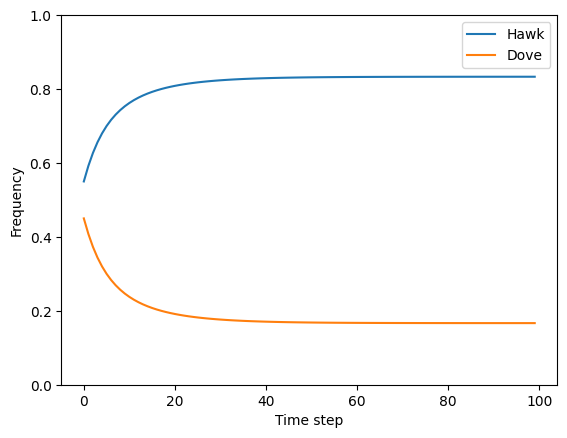

In [127]:
plot_pd_dynamics(hawk_dove_proportions)